In [1]:
import math, copy
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
from lab_utils_uni import plt_house_x, plt_contour_wgrad, plt_divergence, plt_gradients

In [2]:
x_train = np.array([1.0, 2.0])
y_train = np.array([300.0, 500.0])


In [3]:
def compute_cost (x, y, w, b):
    m = x.shape[0]
    cost = 0

    for i in range (m):
        f_wb = w * x[i] + b
        cost = cost + (f_wb - y[i]) ** 2
    total_cost = 1 / (2 * m) * cost
    return total_cost
    

In [4]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range (m):
        f_wb = w * x[i] + b
        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = (f_wb -y[i])
        dj_dw += dj_dw_i
        dj_db += dj_db_i
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

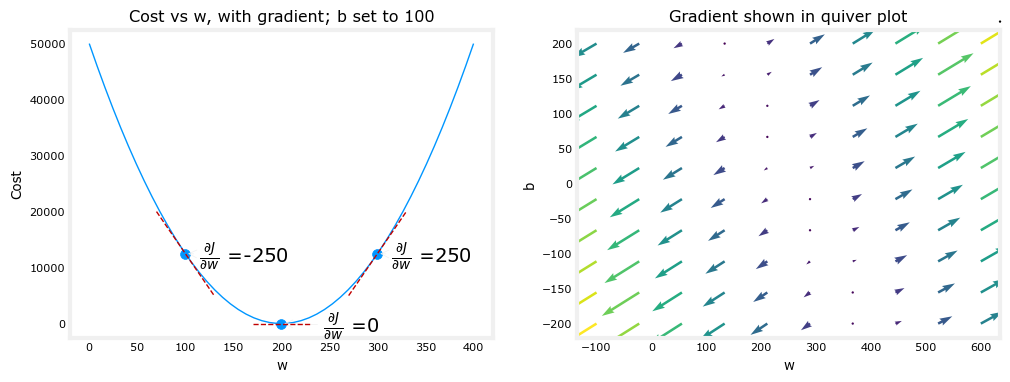

In [5]:
plt_gradients(x_train, y_train, compute_cost, compute_gradient)
plt.show()

In [6]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
    """
    performs gradient descent fit w, b. updates w, b by talking 
    num_iters gradient steps with learning rate alpha 
    Args :
    x(ndarray (m,)) : data m examples 
    y(ndarray(m,)) : target value 
    w_in, b_in (scaler) : initial values of model parameters 
    alpha (float) : Learning rate
    num_iters (int) : number of iterations to run gradient descent
    cost function : function to call tonproduce cost
    gradient_function : function to call to gradient 

    Returns :
    w (scalar) : updated value of parameter after running gradient descent  
    b (scalar) : updated value of parameter after running gradient descent
    J_history (list) : history of cost value 
    P_history (list) : history of parameters [w, b]
    """
    # an array to store cost J w's at each iteration primerily for graphing later
    J_History = []
    P_history = []
    w = w_in
    b = b_in

    for i in range(num_iters):
        #calculate the gradieint and update the parameter using gradient function
        dj_dw, dj_db = gradient_function(x, y, w, b)
        #update parameters
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        #save cost at each iteration
        if i< 100000:
            J_History.append(cost_function(x, y, w, b))
            P_history.append([w,b])
            
            if i% math.ceil (num_iters/10) == 0:
                print (f"iteration {i:4}, cost{J_History[-1]:0.2e}" , f"dj_dw :{dj_dw : 0.3e}, dj_db : {dj_db : 0.3e}" , 
                       f"w :{w : 0.5e} , b: {b : 0.5e}" )
    return w, b, J_History, P_history


In [7]:
w_init = 0
b_init = 0
iterations = 10000
tmp_alpha = 1.0e-2 
w_final, b_final, J_hist, P_hist = gradient_descent(x_train, y_train, w_init, b_init, tmp_alpha, iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

iteration    0, cost7.93e+04 dj_dw :-6.500e+02, dj_db : -4.000e+02 w : 6.50000e+00 , b:  4.00000e+00
iteration 1000, cost3.41e+00 dj_dw :-3.712e-01, dj_db :  6.007e-01 w : 1.94915e+02 , b:  1.08228e+02
iteration 2000, cost7.93e-01 dj_dw :-1.789e-01, dj_db :  2.895e-01 w : 1.97549e+02 , b:  1.03966e+02
iteration 3000, cost1.84e-01 dj_dw :-8.625e-02, dj_db :  1.396e-01 w : 1.98818e+02 , b:  1.01912e+02
iteration 4000, cost4.28e-02 dj_dw :-4.158e-02, dj_db :  6.727e-02 w : 1.99430e+02 , b:  1.00922e+02
iteration 5000, cost9.95e-03 dj_dw :-2.004e-02, dj_db :  3.243e-02 w : 1.99725e+02 , b:  1.00444e+02
iteration 6000, cost2.31e-03 dj_dw :-9.660e-03, dj_db :  1.563e-02 w : 1.99868e+02 , b:  1.00214e+02
iteration 7000, cost5.37e-04 dj_dw :-4.657e-03, dj_db :  7.535e-03 w : 1.99936e+02 , b:  1.00103e+02
iteration 8000, cost1.25e-04 dj_dw :-2.245e-03, dj_db :  3.632e-03 w : 1.99969e+02 , b:  1.00050e+02
iteration 9000, cost2.90e-05 dj_dw :-1.082e-03, dj_db :  1.751e-03 w : 1.99985e+02 , b:  1.

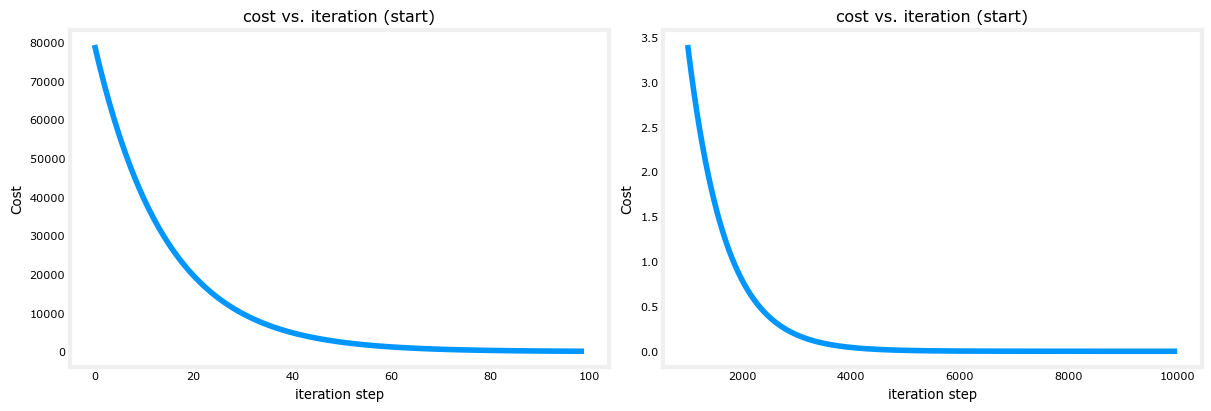

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout = True, figsize = (12, 4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax1.set_title("cost vs. iteration (start)") ; ax2.set_title("cost vs. iteration (start)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step') 
plt.show()

In [9]:
print(f"1000 sqft house pridiction {w_final * 1.0 + b_final:0.1f} thousand dollars")
print(f"1200 sqft house pridiction {w_final * 1.2 + b_final:0.1f} thousand dollars")
print(f"2000 sqft house pridiction {w_final * 2.0 + b_final:0.1f} thousand dollars")

1000 sqft house pridiction 300.0 thousand dollars
1200 sqft house pridiction 340.0 thousand dollars
2000 sqft house pridiction 500.0 thousand dollars


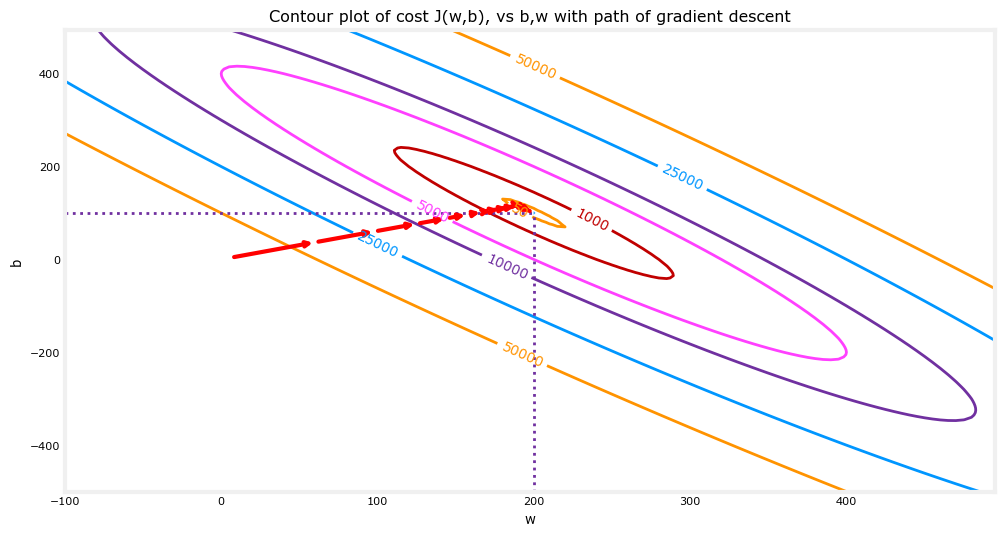

In [10]:
fig, ax = plt.subplots(1, 1, figsize = (12, 6 ))
plt_contour_wgrad(x_train, y_train, P_hist, ax)

In [11]:
w_init = 0
b_init = 0
iteartion = 10
tmp_alpha = 8.0e-1
w_final, b_final,J_hist, P_hist = gradient_descent(x_train, y_train, w_init, b_init, tmp_alpha, iteartion, compute_cost, compute_gradient)

iteration    0, cost2.58e+05 dj_dw :-6.500e+02, dj_db : -4.000e+02 w : 5.20000e+02 , b:  3.20000e+02
iteration    1, cost7.82e+05 dj_dw : 1.130e+03, dj_db :  7.000e+02 w :-3.84000e+02 , b: -2.40000e+02
iteration    2, cost2.37e+06 dj_dw :-1.970e+03, dj_db : -1.216e+03 w : 1.19200e+03 , b:  7.32800e+02
iteration    3, cost7.19e+06 dj_dw : 3.429e+03, dj_db :  2.121e+03 w :-1.55136e+03 , b: -9.63840e+02
iteration    4, cost2.18e+07 dj_dw :-5.974e+03, dj_db : -3.691e+03 w : 3.22797e+03 , b:  1.98886e+03
iteration    5, cost6.62e+07 dj_dw : 1.040e+04, dj_db :  6.431e+03 w :-5.09460e+03 , b: -3.15579e+03
iteration    6, cost2.01e+08 dj_dw :-1.812e+04, dj_db : -1.120e+04 w : 9.40155e+03 , b:  5.80237e+03
iteration    7, cost6.09e+08 dj_dw : 3.156e+04, dj_db :  1.950e+04 w :-1.58444e+04 , b: -9.80139e+03
iteration    8, cost1.85e+09 dj_dw :-5.496e+04, dj_db : -3.397e+04 w : 2.81261e+04 , b:  1.73730e+04
iteration    9, cost5.60e+09 dj_dw : 9.572e+04, dj_db :  5.916e+04 w :-4.84537e+04 , b: -2.

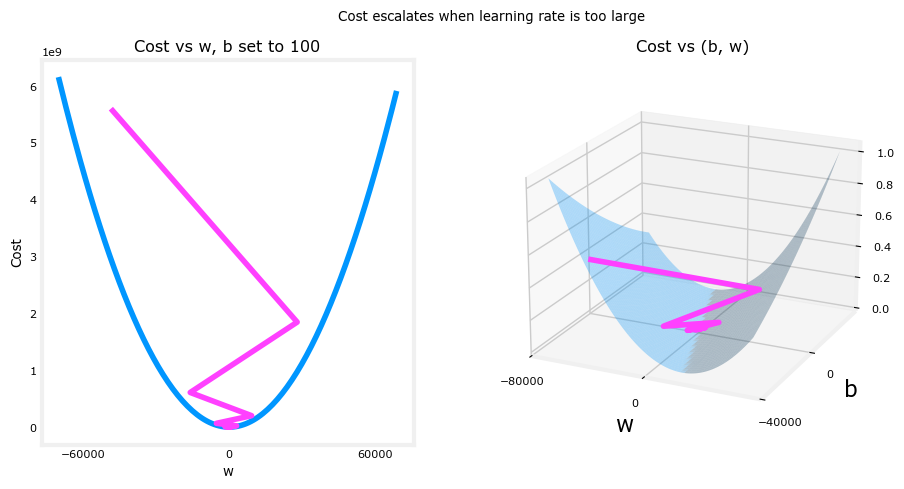

In [12]:
plt_divergence(P_hist, J_hist, x_train, y_train, )
plt.show()